In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
df = pd.read_csv("Online_Retail.csv")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
#DATA CLEANING 
#Cell: Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

In [5]:
#CHECK
df.shape

(406829, 8)

In [6]:
#REMOVE CANCELLED INVOICES
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [7]:
#REMOVE INVALID VALUES 
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [8]:
#DATE CONVERSION
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
#FEATURE ENGINEERING
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
#EDA (Exploratory Data Analysis)

In [13]:
#Country-wise Transactions (Top 10)
df['Country'].value_counts().head(10)

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64

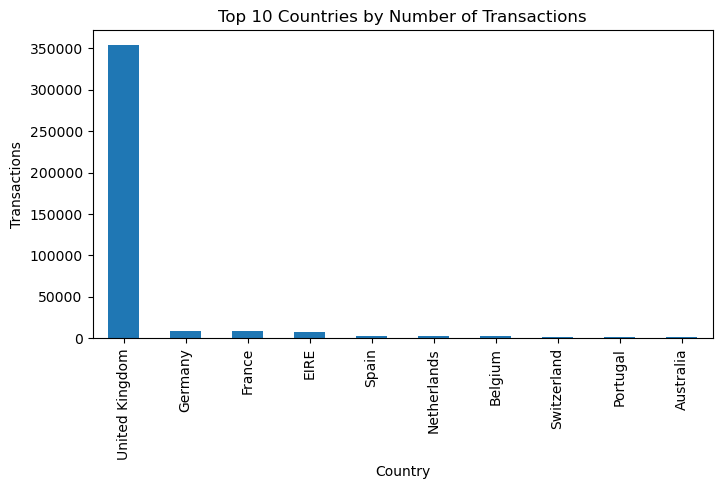

In [15]:
#Country-wise Transactions Plot
df['Country'].value_counts().head(10).plot(kind='bar', figsize=(8,4))
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Transactions")
plt.show()


United Kingdom dominates the transaction volume compared to other countries.

In [17]:
#Top-Selling Products
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

C:\Users\Suyash Y. Labhane\AppData\Local\Temp\ipykernel_11684\1880918554.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('InvoiceDate').resample('M')['InvoiceNo'].count().plot(figsize=(8,4))


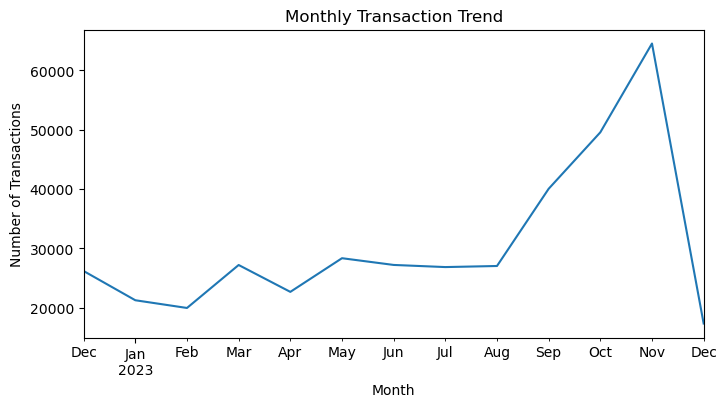

In [19]:
#Monthly Purchase Trend
df.set_index('InvoiceDate').resample('M')['InvoiceNo'].count().plot(figsize=(8,4))
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()


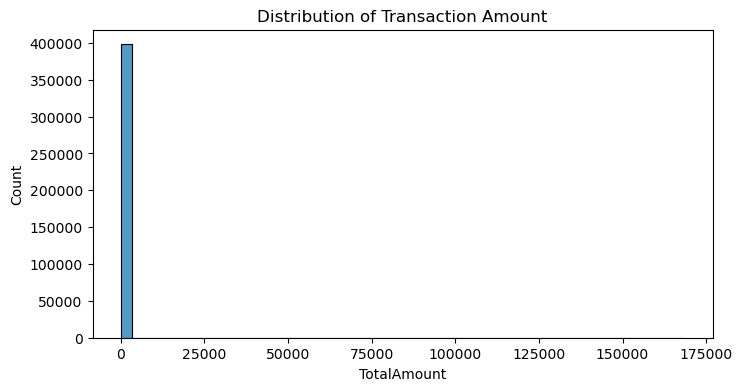

In [20]:
# Transaction Amount Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['TotalAmount'], bins=50)
plt.title("Distribution of Transaction Amount")
plt.show()


Most transactions have a low monetary value, indicating frequent small purchases.

RFM ANALYSIS

In [21]:
# RFM table
latest_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


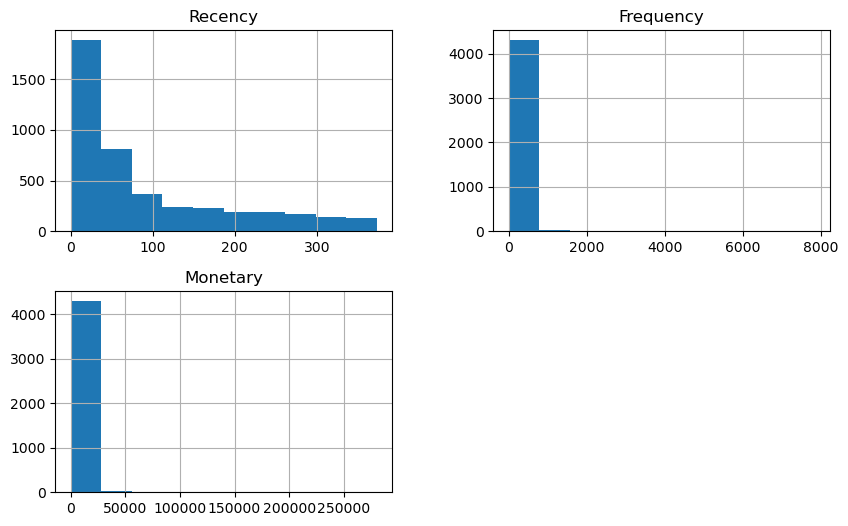

In [22]:
#RFM Distributions
rfm.hist(figsize=(10,6))
plt.show()


In [23]:
#RFM STANDARDIZATION
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


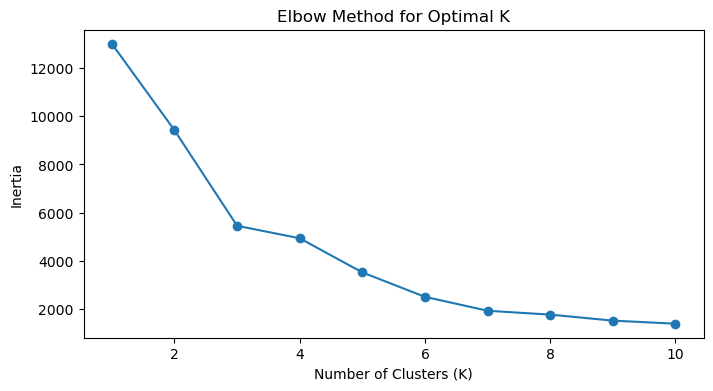

In [24]:
#ELBOW METHOD (Cluster Count Decide)
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


The elbow curve suggests that K=4 is an optimal number of clusters.

In [25]:
# KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)


In [26]:
# MODEL EVALUATION
#Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_score(rfm_scaled, rfm['Cluster'])


np.float64(0.3588023011776161)

In [27]:
#CLUSTER INTERPRETATION
#Cluster-wise RFM Mean
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,19.990788,135.285122,2645.818172
1,97.218703,37.719457,773.877083
2,3.692308,2565.307692,126118.310000
3,271.407005,25.138889,605.842525


In [28]:
#CUSTOMER SEGMENTS
#Assign Meaningful Labels
cluster_map = {
    0: 'High-Value',
    1: 'Regular',
    2: 'Occasional',
    3: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_map)
rfm.head()


,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,325,1,77183.60,3,At-Risk
12347.0,1,182,4310.00,0,High-Value
12348.0,74,31,1797.24,1,Regular
12349.0,18,73,1757.55,0,High-Value
12350.0,309,17,334.40,3,At-Risk


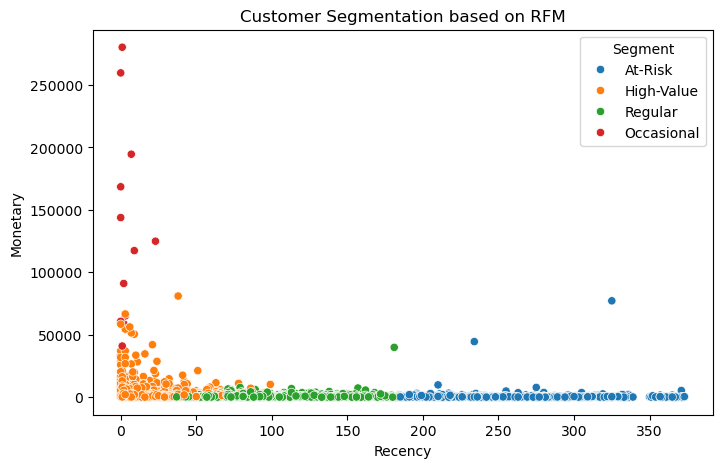

In [29]:
#CLUSTER VISUALIZATION
#Cluster Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=rfm['Recency'],
    y=rfm['Monetary'],
    hue=rfm['Segment']
)
plt.title("Customer Segmentation based on RFM")
plt.show()


In [30]:
#Customer–Product Pivot Table
pivot_table = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    fill_value=0
)

pivot_table.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12347.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12349.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
#Cosine Similarity (Item-Based)
from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(pivot_table.T)

product_similarity_df = pd.DataFrame(
    product_similarity,
    index=pivot_table.columns,
    columns=pivot_table.columns
)


In [32]:
#Recommendation Function
def recommend_products(product_name, top_n=5):
    similar_scores = product_similarity_df[product_name].sort_values(ascending=False)
    return similar_scores[1:top_n+1]

In [34]:
# Test Recommendation
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")

Description
GIN + TONIC DIET METAL SIGN           0.935872
TEA TIME TEA TOWELS                   0.925193
FAIRY CAKE FLANNEL ASSORTED COLOUR    0.914906
DOORMAT FAIRY CAKE                    0.888525
RED HANGING HEART T-LIGHT HOLDER      0.258613
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

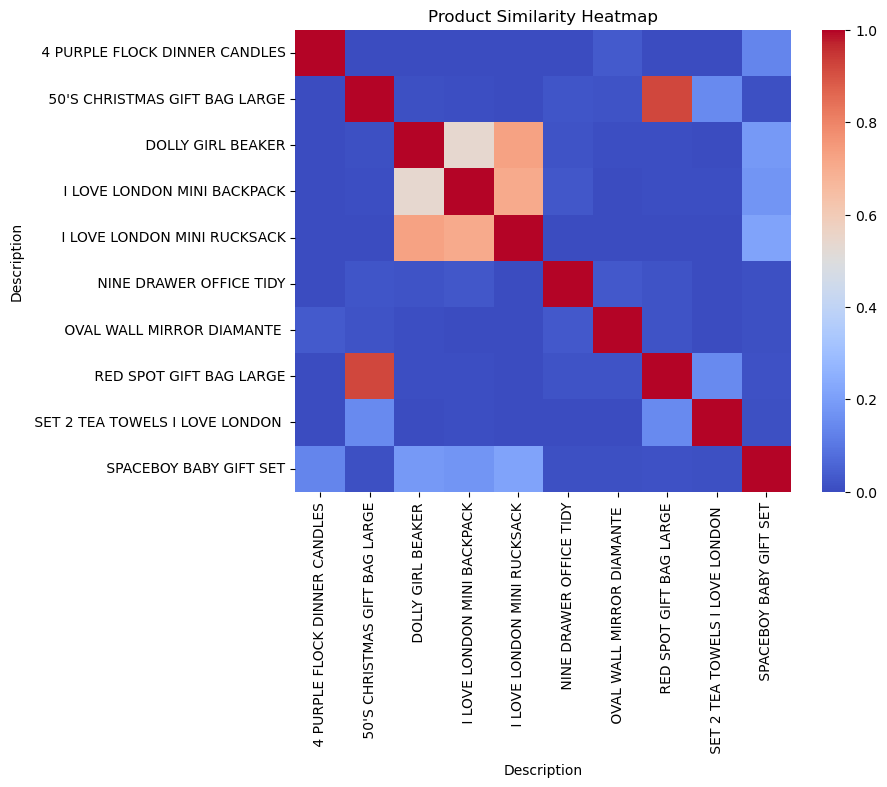

In [35]:
#Similarity Heatmap (Optional but IMPRESSIVE)
plt.figure(figsize=(8,6))
sns.heatmap(
    product_similarity_df.iloc[:10, :10],
    cmap='coolwarm'
)
plt.title("Product Similarity Heatmap")
plt.show()


Key Insights

- High-Value customers show frequent, recent, and high-spending behavior.
- At-Risk customers have low frequency and long inactivity periods.
- RFM-based clustering effectively segments customers for targeted strategies.
- Collaborative filtering successfully recommends similar products based on purchase history.

Business Use Cases

- Personalized product recommendations
- Targeted marketing campaigns
- Customer retention strategies
- Inventory and demand forecasting

Conclusion

This project demonstrates how e-commerce transaction data can be leveraged
to perform customer segmentation and product recommendation using
unsupervised machine learning techniques.
